# Gas Prices — Exploratory Data Analysis

**Goal:** Determine if cities within the same province are close enough to collapse into a provincial median, then use those medians to analyse price patterns and event-driven spikes over time.

**Key findings summary:**
- Provincial medians are justified (CV < 5.3% across all provinces)
- All provinces move together on global events — national median is the right unit of analysis
- Supply conflicts with direct oil proximity produce pre-event price signals; demand shocks and indirect conflicts do not
- Pre-event signal for Ukraine invasion starts at T-12w, not T-8w

## Cell 1 — Imports and paths

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

BASE_DIR         = Path().resolve()
processed_folder = BASE_DIR / 'data' / 'processed'
figures_folder   = BASE_DIR / 'figures'
figures_folder.mkdir(exist_ok=True)

print(f'Processed : {processed_folder}')
print(f'Figures   : {figures_folder}')

Processed : /Users/btosi/projects/gas_price/data/processed
Figures   : /Users/btosi/projects/gas_price/figures


## Cell 2 — Load data

In [2]:
df = pd.read_csv(
    processed_folder / 'gas_prices_all_years.csv',
    index_col='date',
    parse_dates=True
)

print(f'Shape     : {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'Columns   : {len(df.columns)}')

Shape     : (1409, 82)
Date range: 2000-01-04 → 2026-12-29
Columns   : 82


## Cell 3 — Province mapping and medians

Map each city to its province and compute provincial medians.
These are used throughout the rest of the notebook.

In [3]:
PROVINCES = {
    'BC'  : ['VANCOUVER', 'VICTORIA', 'PRINCE GEORGE', 'KAMLOOPS', 'KELOWNA', 'ABBOTSFORD', 'FORT ST. JOHN'],
    'AB'  : ['CALGARY', 'EDMONTON', 'RED DEER', 'LETHBRIDGE', 'GRANDE PRAIRIE', 'LLOYDMINSTER'],
    'SK'  : ['REGINA', 'SASKATOON', 'PRINCE ALBERT', 'MOOSE JAW'],
    'MB'  : ['WINNIPEG', 'BRANDON'],
    'ON'  : ['CITY OF TORONTO', 'OTTAWA', 'WINDSOR', 'LONDON', 'SUDBURY', 'SAULT STE MARIE',
             'THUNDER BAY', 'NORTH BAY', 'TIMMINS', 'HAMILTON', 'ST. CATHARINES',
             'BARRIE', 'BRANTFORD', 'GUELPH', 'KITCHENER', 'KINGSTON',
             'OSHAWA', 'PETERBOROUGH', 'PEEL REGION'],
    'QC'  : ['MONTRÉAL', 'QUÉBEC', 'SHERBROOKE', 'GASPÉ', 'CHICOUTIMI', 'RIMOUSKI',
             'TROIS RIVIÈRES', 'DRUMMONDVILLE', "VAL D'OR", 'GATINEAU'],
    'NB'  : ['SAINT JOHN', 'FREDERICTON', 'MONCTON', 'BATHURST', 'EDMUNDSTON',
             'MIRAMICHI', 'CAMPBELLTON', 'SUSSEX', 'WOODSTOCK'],
    'NS'  : ['HALIFAX', 'SYDNEY', 'YARMOUTH', 'TRURO', 'KENTVILLE', 'NEW GLASGOW'],
    'PEI' : ['CHARLOTTETOWN'],
    'NL'  : ['ST JOHNS', 'GANDER', 'CORNER BROOK', 'GRAND FALLS', 'LABRADOR CITY'],
    'YT'  : ['WHITEHORSE'],
    'NT'  : ['YELLOWKNIFE'],
}

for prov, cities in PROVINCES.items():
    available = [c for c in cities if c in df.columns]
    df[f'{prov}_median'] = df[available].median(axis=1)

prov_medians = [f'{p}_median' for p in PROVINCES]
print('✅ Provincial medians computed')
print(prov_medians)

✅ Provincial medians computed
['BC_median', 'AB_median', 'SK_median', 'MB_median', 'ON_median', 'QC_median', 'NB_median', 'NS_median', 'PEI_median', 'NL_median', 'YT_median', 'NT_median']


## Cell 4 — Event definitions

All global events covered in this analysis, with type and oil proximity classification.

- **event_type**: `supply_conflict`, `supply_disruption`, `demand_shock`, `policy`
- **oil_proximity**: `direct`, `moderate`, `indirect`

In [4]:
EVENTS = {
    '9/11 attacks'          : '2001-09-11',
    'Iraq War'              : '2003-03-20',
    'Hurricane Katrina'     : '2005-08-29',
    '2008 financial crisis' : '2008-09-15',
    'Arab Spring / Libya'   : '2011-02-17',
    'Crimea annexation'     : '2014-03-18',
    'OPEC production cut'   : '2016-11-30',
    'US-Iran / Soleimani'   : '2020-01-03',
    'COVID-19'              : '2020-03-15',
    'Ukraine invasion'      : '2022-02-24',
    'Gaza conflict'         : '2023-10-07',
}

EVENT_TYPES = {
    '9/11 attacks'          : 'demand_shock',
    'Iraq War'              : 'supply_conflict',
    'Hurricane Katrina'     : 'supply_disruption',
    '2008 financial crisis' : 'demand_shock',
    'Arab Spring / Libya'   : 'supply_conflict',
    'Crimea annexation'     : 'supply_conflict',
    'OPEC production cut'   : 'policy',
    'US-Iran / Soleimani'   : 'supply_conflict',
    'COVID-19'              : 'demand_shock',
    'Ukraine invasion'      : 'supply_conflict',
    'Gaza conflict'         : 'supply_conflict',
}

OIL_PROXIMITY = {
    '9/11 attacks'          : 'indirect',
    'Iraq War'              : 'direct',
    'Hurricane Katrina'     : 'direct',
    '2008 financial crisis' : 'indirect',
    'Arab Spring / Libya'   : 'direct',
    'Crimea annexation'     : 'indirect',
    'OPEC production cut'   : 'direct',
    'US-Iran / Soleimani'   : 'moderate',
    'COVID-19'              : 'indirect',
    'Ukraine invasion'      : 'direct',
    'Gaza conflict'         : 'indirect',
}

print('✅ Events defined:', list(EVENTS.keys()))

✅ Events defined: ['9/11 attacks', 'Iraq War', 'Hurricane Katrina', '2008 financial crisis', 'Arab Spring / Libya', 'Crimea annexation', 'OPEC production cut', 'US-Iran / Soleimani', 'COVID-19', 'Ukraine invasion', 'Gaza conflict']


## Cell 5 — Within-province dispersion

CV (coefficient of variation) measures relative spread within each province.
CV < 5% consistently → provincial median is justified.

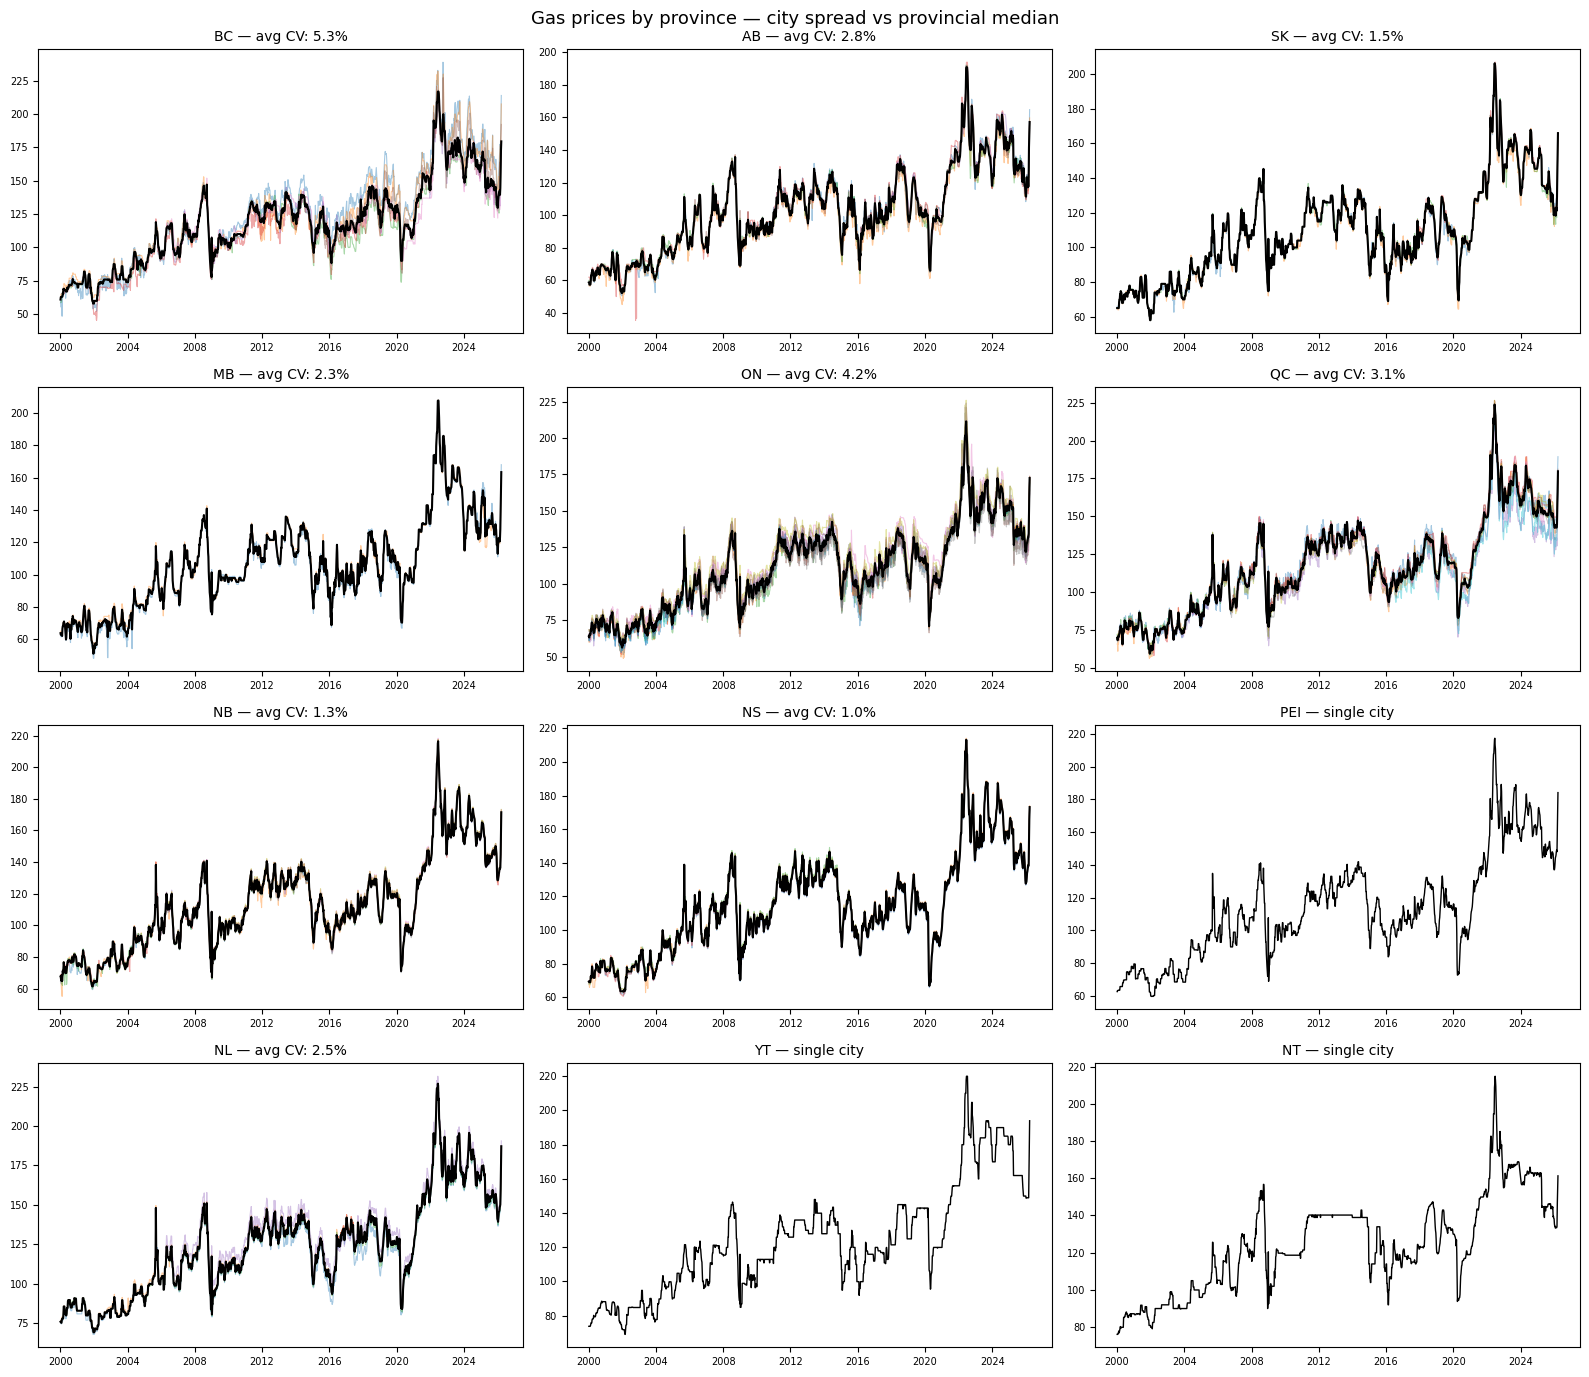

✅ Saved to figures/province_dispersion.png


In [5]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, (prov, cities) in enumerate(PROVINCES.items()):
    available = [c for c in cities if c in df.columns]
    ax = axes[i]

    if len(available) > 1:
        for city in available:
            ax.plot(df.index, df[city], alpha=0.4, linewidth=0.8)
        ax.plot(df.index, df[f'{prov}_median'], color='black', linewidth=1.5, label='median')
        cv = (df[available].std(axis=1) / df[available].mean(axis=1) * 100).mean()
        ax.set_title(f'{prov} — avg CV: {cv:.1f}%', fontsize=10)
    else:
        ax.plot(df.index, df[available[0]], color='black', linewidth=1)
        ax.set_title(f'{prov} — single city', fontsize=10)

    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Gas prices by province — city spread vs provincial median', fontsize=13)
plt.tight_layout()
plt.savefig(figures_folder / 'province_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to figures/province_dispersion.png')

## Cell 6 — Provincial medians over time

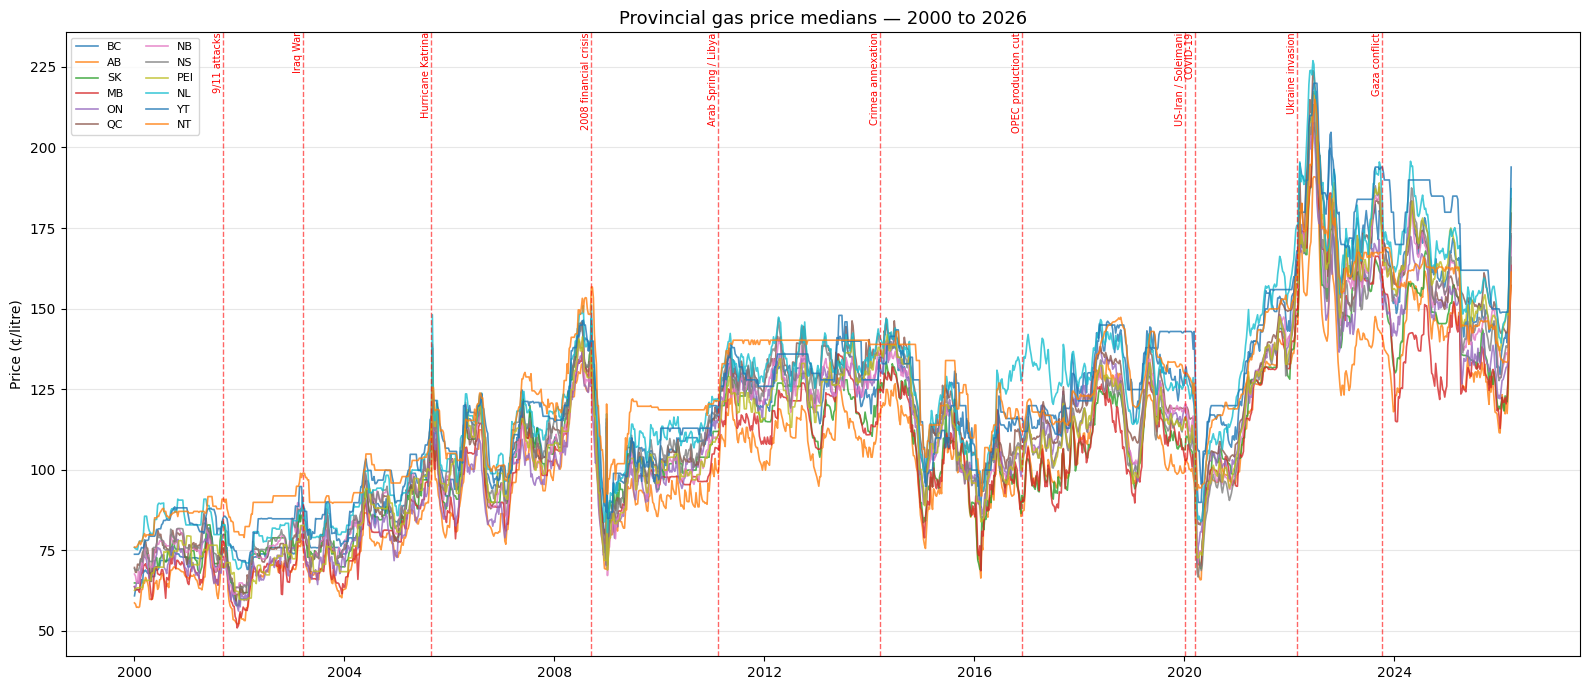

✅ Saved to figures/provincial_medians.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 7))

for prov in PROVINCES:
    ax.plot(df.index, df[f'{prov}_median'], linewidth=1.2, label=prov, alpha=0.8)

for label, date in EVENTS.items():
    ax.axvline(pd.Timestamp(date), color='red', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1], label, rotation=90,
            fontsize=7, color='red', va='top', ha='right')

ax.set_title('Provincial gas price medians — 2000 to 2026', fontsize=13)
ax.set_ylabel('Price (¢/litre)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_folder / 'provincial_medians.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to figures/provincial_medians.png')

## Cell 7 — Event windows (6 months before and after)

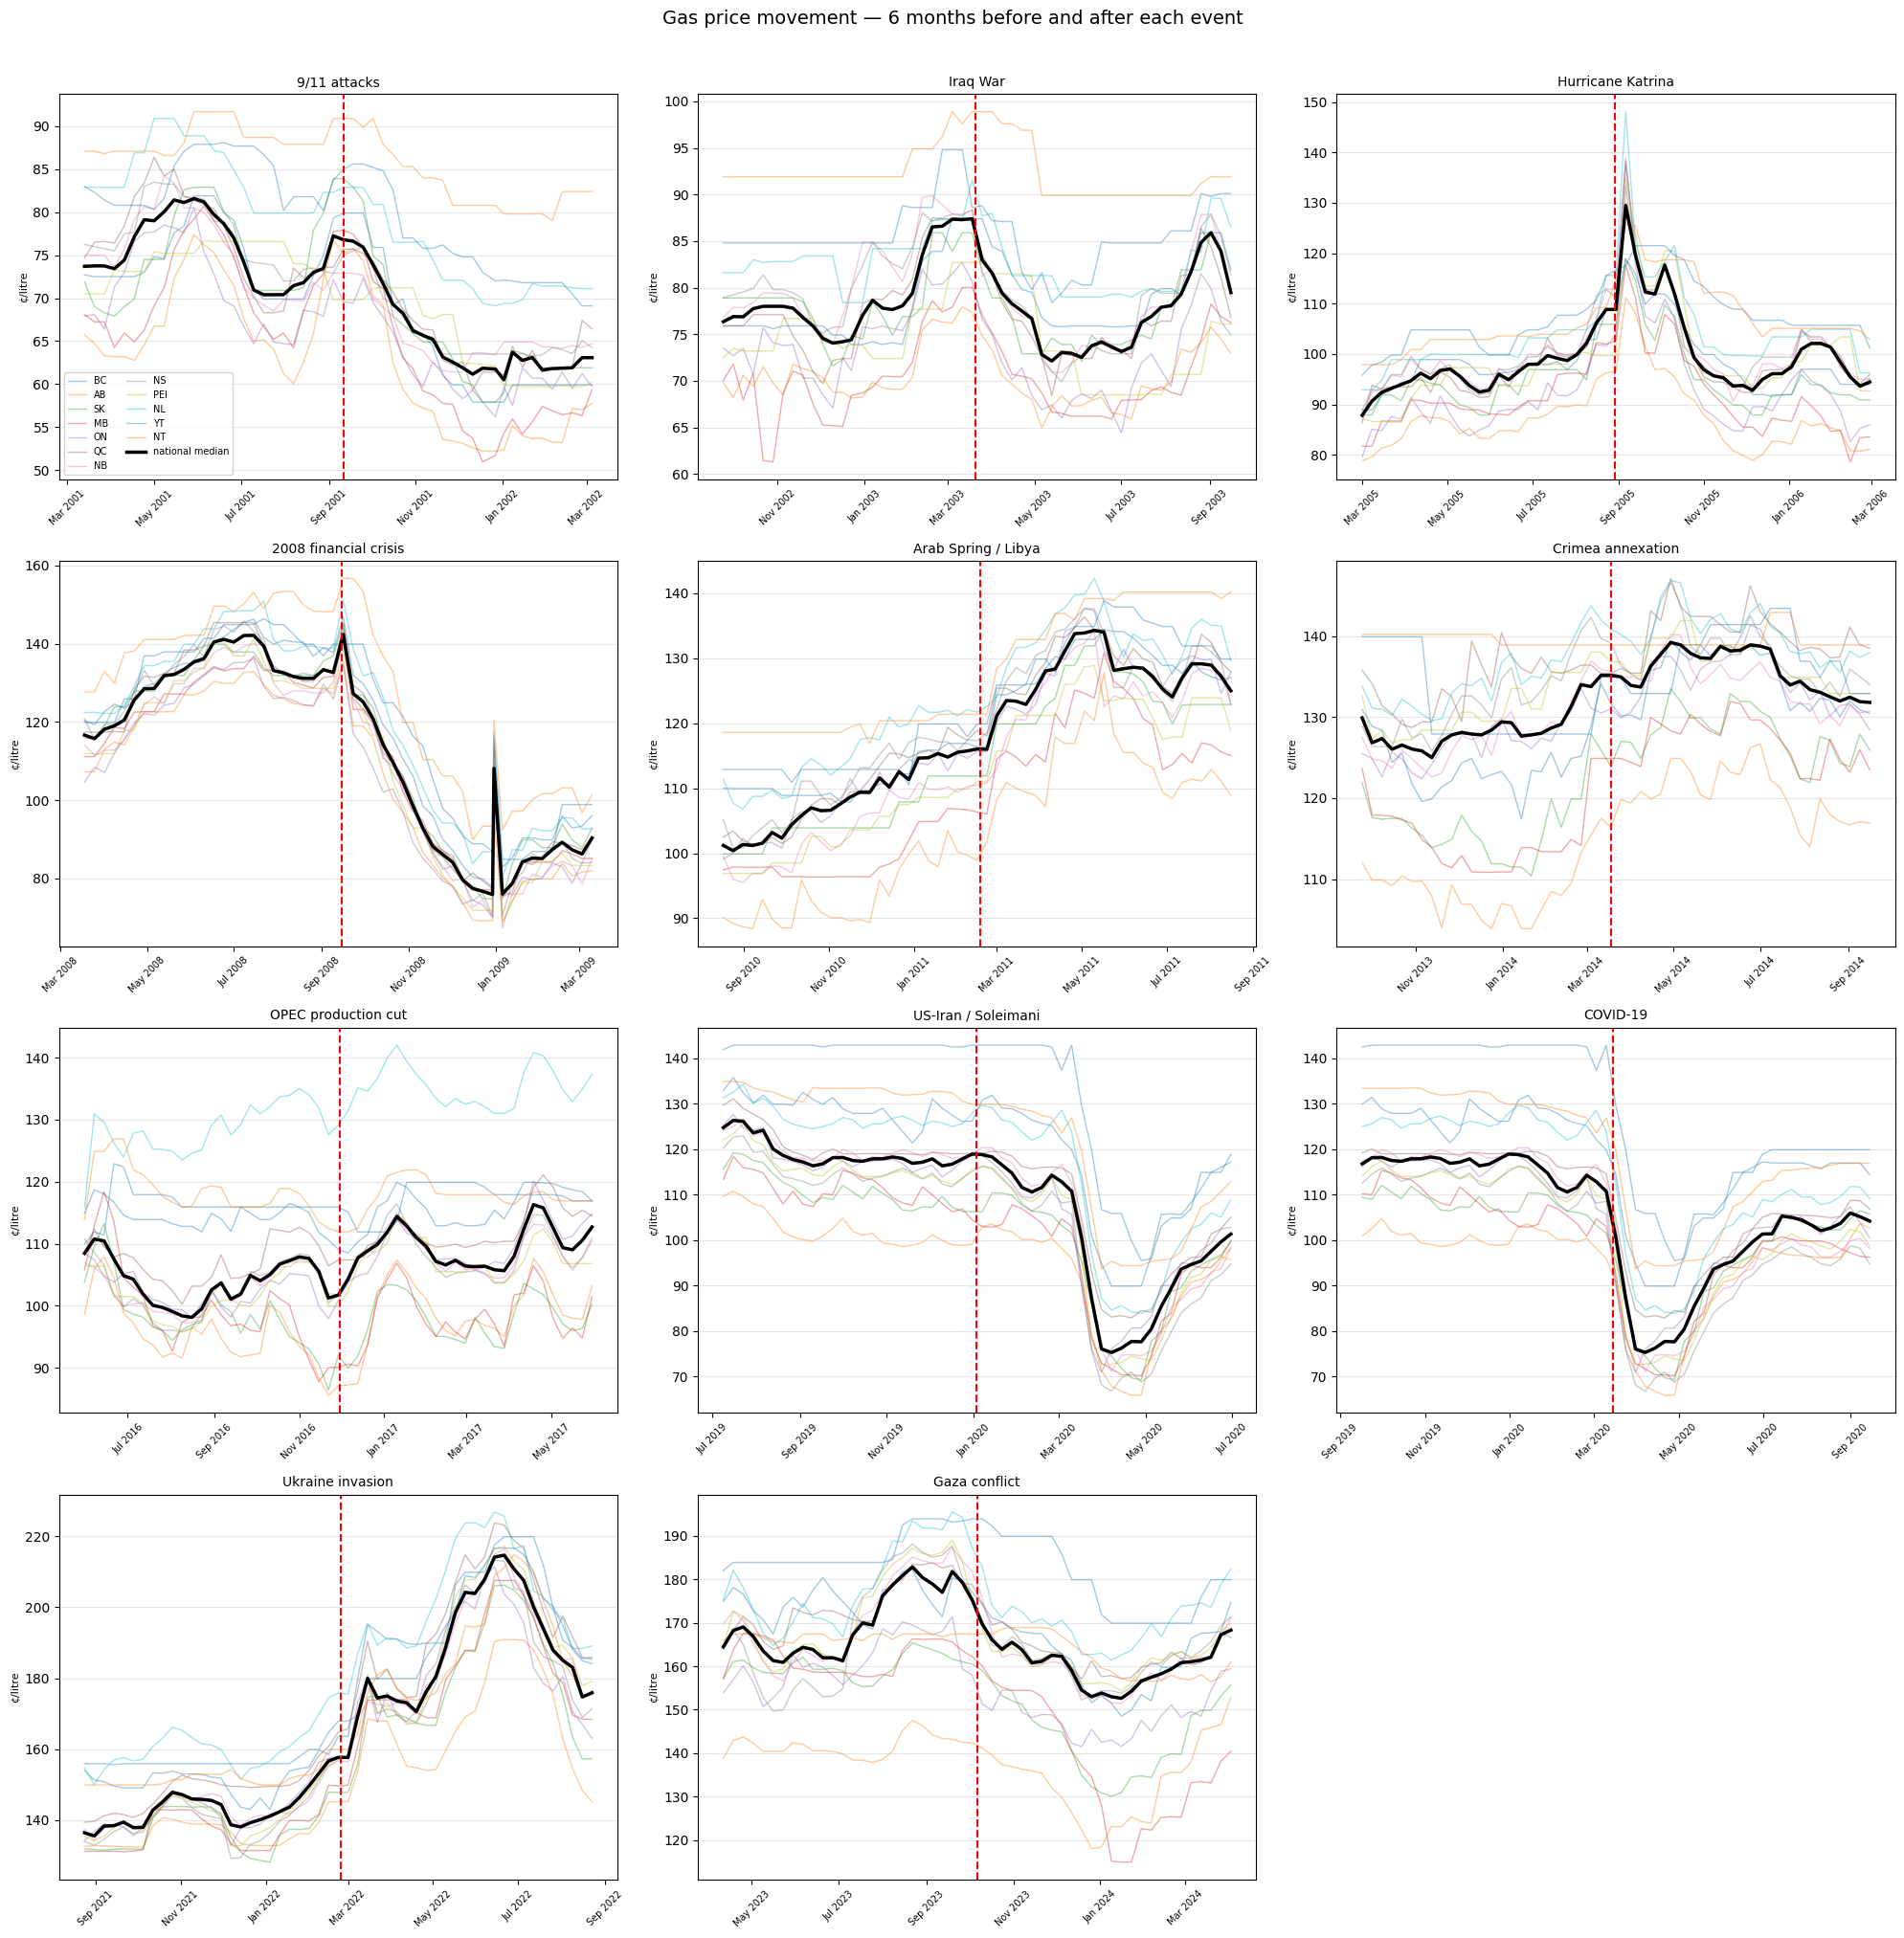

✅ Saved to figures/event_windows.png


In [7]:
fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()

for ax, (label, date) in zip(axes, EVENTS.items()):
    event_date = pd.Timestamp(date)
    window     = df.loc[event_date - pd.DateOffset(months=6) : event_date + pd.DateOffset(months=6)]

    for prov in PROVINCES:
        ax.plot(window.index, window[f'{prov}_median'], linewidth=1, alpha=0.4, label=prov)

    national = window[[f'{p}_median' for p in PROVINCES]].median(axis=1)
    ax.plot(window.index, national, color='black', linewidth=2.5, label='national median')
    ax.axvline(event_date, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('¢/litre', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
axes[0].legend(fontsize=7, ncol=2)
plt.suptitle('Gas price movement — 6 months before and after each event', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(figures_folder / 'event_windows.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to figures/event_windows.png')

## Cell 8 — Pre vs post event price change (quantified)

In [8]:
national = df[[f'{p}_median' for p in PROVINCES]].median(axis=1)
results  = []

for label, date in EVENTS.items():
    event_date  = pd.Timestamp(date)
    t_8w        = national.loc[event_date - pd.DateOffset(weeks=8)  : event_date].mean()
    t_4w        = national.loc[event_date - pd.DateOffset(weeks=4)  : event_date].mean()
    t_2w        = national.loc[event_date - pd.DateOffset(weeks=2)  : event_date].mean()
    t_0         = national.loc[event_date - pd.DateOffset(weeks=1)  : event_date + pd.DateOffset(weeks=1)].mean()
    t_4w_after  = national.loc[event_date : event_date + pd.DateOffset(weeks=4)].mean()
    t_12w_after = national.loc[event_date : event_date + pd.DateOffset(weeks=12)].mean()

    results.append({
        'event'           : label,
        'date'            : date,
        'event_type'      : EVENT_TYPES[label],
        'oil_proximity'   : OIL_PROXIMITY[label],
        'price_8w_before' : round(t_8w, 1),
        'price_4w_before' : round(t_4w, 1),
        'price_2w_before' : round(t_2w, 1),
        'price_at_event'  : round(t_0, 1),
        'price_4w_after'  : round(t_4w_after, 1),
        'price_12w_after' : round(t_12w_after, 1),
        'change_pre_8w'   : round(t_0 - t_8w, 1),
        'change_pre_4w'   : round(t_0 - t_4w, 1),
        'change_post_12w' : round(t_12w_after - t_0, 1),
    })

df_events = pd.DataFrame(results).set_index('event')
print(df_events[['date', 'event_type', 'oil_proximity', 'change_pre_8w', 'change_post_12w']].to_string())

                             date         event_type oil_proximity  change_pre_8w  change_post_12w
event                                                                                             
9/11 attacks           2001-09-11       demand_shock      indirect            4.1             -7.9
Iraq War               2003-03-20    supply_conflict        direct            0.7             -9.0
Hurricane Katrina      2005-08-29  supply_disruption        direct            7.3             -0.2
2008 financial crisis  2008-09-15       demand_shock      indirect            4.4            -29.7
Arab Spring / Libya    2011-02-17    supply_conflict        direct            1.2             10.8
Crimea annexation      2014-03-18    supply_conflict      indirect            3.7              1.8
OPEC production cut    2016-11-30             policy        direct           -2.4              6.3
US-Iran / Soleimani    2020-01-03    supply_conflict      moderate            1.4             -8.2
COVID-19  

## Cell 9 — Pre vs post change bar chart

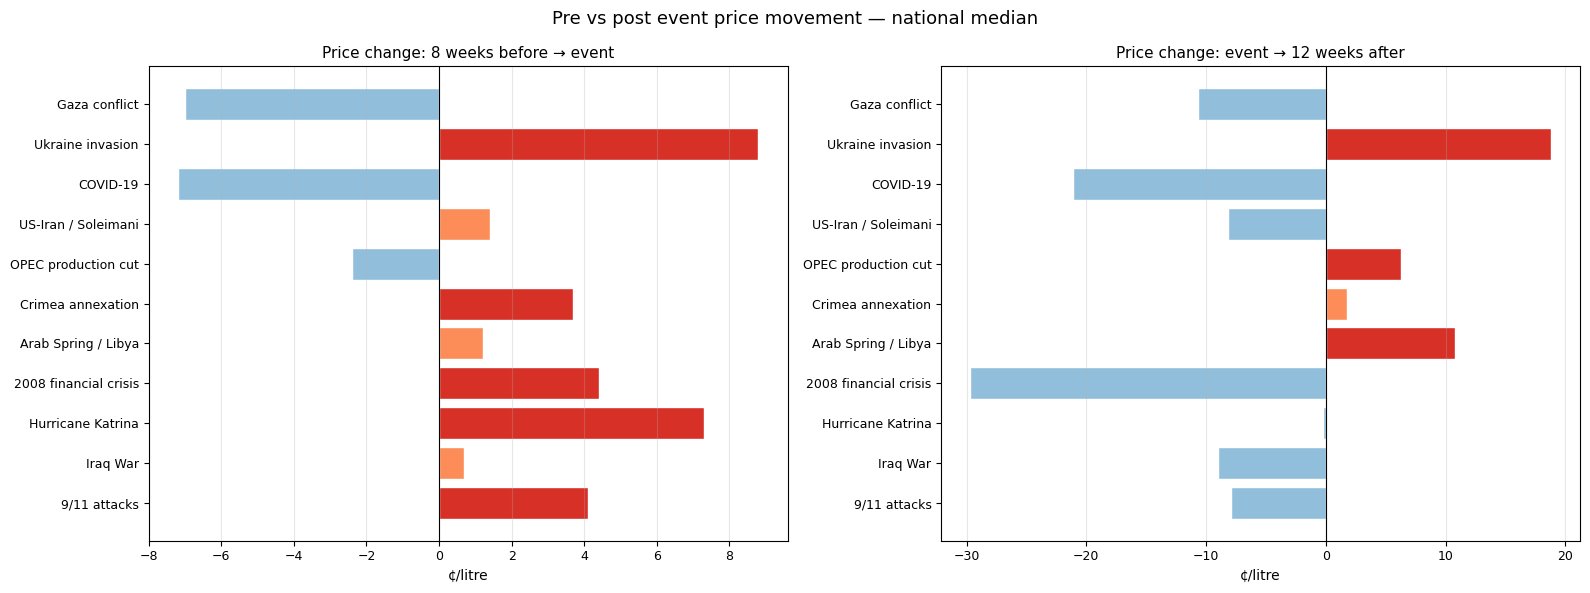

✅ Saved to figures/pre_post_event_change.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_pre  = ['#d73027' if x > 3 else '#fc8d59' if x > 0 else '#91bfdb' for x in df_events['change_pre_8w']]
colors_post = ['#d73027' if x > 5 else '#fc8d59' if x > 0 else '#91bfdb' for x in df_events['change_post_12w']]

axes[0].barh(df_events.index, df_events['change_pre_8w'], color=colors_pre, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Price change: 8 weeks before → event', fontsize=11)
axes[0].set_xlabel('¢/litre')
axes[0].tick_params(labelsize=9)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(df_events.index, df_events['change_post_12w'], color=colors_post, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Price change: event → 12 weeks after', fontsize=11)
axes[1].set_xlabel('¢/litre')
axes[1].tick_params(labelsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Pre vs post event price movement — national median', fontsize=13)
plt.tight_layout()
plt.savefig(figures_folder / 'pre_post_event_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to figures/pre_post_event_change.png')

## Cell 10 — Ukraine invasion: normalized province reaction

Normalized to 100 at event date to compare reaction speed across provinces.

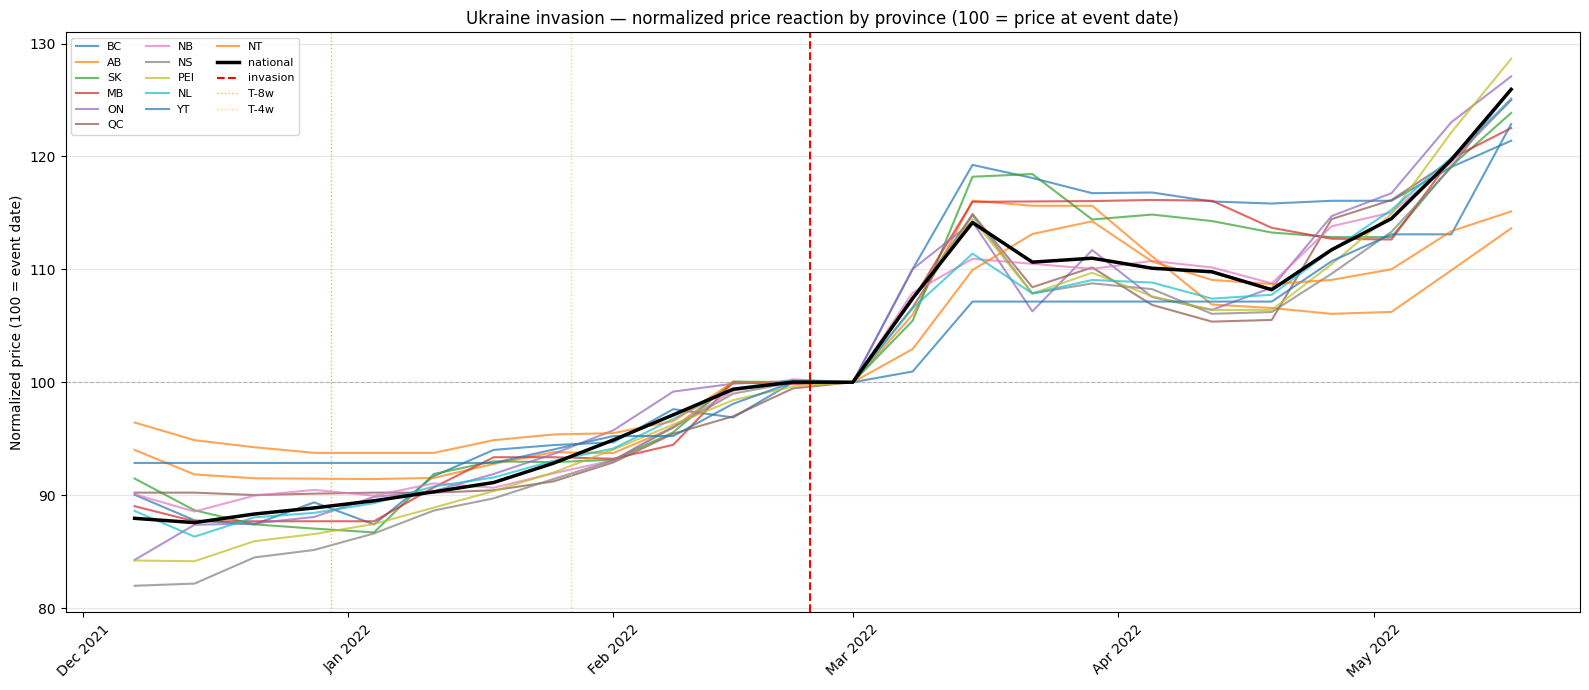

✅ Saved to figures/ukraine_province_reaction.png


In [10]:
event_date = pd.Timestamp('2022-02-24')
window     = df.loc[event_date - pd.DateOffset(weeks=12) : event_date + pd.DateOffset(weeks=12)]

fig, ax = plt.subplots(figsize=(16, 7))

for prov in PROVINCES:
    series = window[f'{prov}_median']
    base   = series.loc[event_date : event_date + pd.DateOffset(days=7)].mean()
    ax.plot(series.index, (series / base) * 100, linewidth=1.5, alpha=0.7, label=prov)

national  = window[[f'{p}_median' for p in PROVINCES]].median(axis=1)
base_nat  = national.loc[event_date : event_date + pd.DateOffset(days=7)].mean()
ax.plot(national.index, (national / base_nat) * 100,
        color='black', linewidth=2.5, label='national', zorder=5)

ax.axvline(event_date, color='red', linewidth=1.5, linestyle='--', label='invasion')
ax.axvline(event_date - pd.DateOffset(weeks=8), color='orange', linewidth=1,
           linestyle=':', alpha=0.8, label='T-8w')
ax.axvline(event_date - pd.DateOffset(weeks=4), color='gold', linewidth=1,
           linestyle=':', alpha=0.8, label='T-4w')
ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_title('Ukraine invasion — normalized price reaction by province (100 = price at event date)', fontsize=12)
ax.set_ylabel('Normalized price (100 = event date)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, ncol=3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(figures_folder / 'ukraine_province_reaction.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to figures/ukraine_province_reaction.png')

## Cell 11 — Average pre/post change by event type and oil proximity

In [11]:
summary = df_events.groupby(['event_type', 'oil_proximity'])[['change_pre_8w', 'change_post_12w']].mean().round(1)
print(summary.to_string())
print('\n--- Core finding ---')
print('supply_conflict + direct  : strongest pre AND post event signal')
print('demand_shock + indirect   : no pre-signal, massive post-event crash')
print('supply_conflict + indirect: no signal in either direction')

                                 change_pre_8w  change_post_12w
event_type        oil_proximity                                
demand_shock      indirect                 0.4            -19.6
policy            direct                  -2.4              6.3
supply_conflict   direct                   3.6              6.9
                  indirect                -1.6             -4.4
                  moderate                 1.4             -8.2
supply_disruption direct                   7.3             -0.2

--- Core finding ---
supply_conflict + direct  : strongest pre AND post event signal
demand_shock + indirect   : no pre-signal, massive post-event crash
supply_conflict + indirect: no signal in either direction
